In [1]:
# ============================================================================
# CELDA 1: INSTALACIÓN Y CONFIGURACIÓN
# ============================================================================

# Instalar dependencias
!pip install -q opencv-python-headless pillow matplotlib seaborn

# Importar librerías
import cv2
import numpy as np
import os
from datetime import datetime
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import io
from google.colab import drive, files
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import zipfile

print("✓ Librerías instaladas e importadas correctamente")

✓ Librerías instaladas e importadas correctamente


In [2]:
# ============================================================================
# CELDA 2: MONTAR GOOGLE DRIVE
# ============================================================================

# Montar Drive
drive.mount('/content/drive')

# Configurar rutas
DRIVE_BASE = '/content/drive/MyDrive'
DATASET_PATH = f'{DRIVE_BASE}/[2526] Datasets OCR'  # Carpeta con mayusculas/minusculas/numeros
MODELS_PATH = f'{DRIVE_BASE}/OCR_Models'  # Donde se guardará el modelo

# Crear carpetas si no existen
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs('temp_results', exist_ok=True)

print(f"✓ Drive montado")
print(f"Dataset path: {DATASET_PATH}")
print(f"Models path: {MODELS_PATH}")

Mounted at /content/drive
✓ Drive montado
Dataset path: /content/drive/MyDrive/[2526] Datasets OCR
Models path: /content/drive/MyDrive/OCR_Models


In [3]:
# ============================================================================
# CELDA 3: CLASES PRINCIPALES DEL SISTEMA
# ============================================================================

class DatasetLoader:
    """Carga el dataset de imágenes de caracteres"""

    def __init__(self, base_path, target_size=(32, 32)):
        self.base_path = base_path
        self.target_size = target_size
        self.char_to_label = {}
        self.label_to_char = {}
        self.images = []
        self.labels = []

    def load_dataset(self):
        """Carga todas las imágenes del dataset"""
        print("Cargando dataset...")
        label_counter = 0

        # Cargar mayúsculas
        mayusculas_path = os.path.join(self.base_path, 'mayusculas')
        if os.path.exists(mayusculas_path):
            label_counter = self._load_category(mayusculas_path, label_counter)
            print(f"✓ Mayúsculas cargadas")

        # Cargar minúsculas
        minusculas_path = os.path.join(self.base_path, 'minusculas')
        if os.path.exists(minusculas_path):
            label_counter = self._load_category(minusculas_path, label_counter)
            print(f"✓ Minúsculas cargadas")

        # Cargar números
        numeros_path = os.path.join(self.base_path, 'numeros')
        if os.path.exists(numeros_path):
            label_counter = self._load_category(numeros_path, label_counter)
            print(f"✓ Números cargados")

        print(f"\n✓ Dataset cargado: {len(self.images)} imágenes, {len(self.char_to_label)} caracteres")

        return np.array(self.images), np.array(self.labels)

    def _load_category(self, category_path, label_counter):
        """Carga una categoría completa"""
        for char_folder in sorted(os.listdir(category_path)):
            char_path = os.path.join(category_path, char_folder)

            if not os.path.isdir(char_path):
                continue

            if char_folder not in self.char_to_label:
                self.char_to_label[char_folder] = label_counter
                self.label_to_char[label_counter] = char_folder
                label_counter += 1

            count = 0
            for img_file in os.listdir(char_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    img_path = os.path.join(char_path, img_file)
                    img = self._load_and_preprocess_image(img_path)

                    if img is not None:
                        self.images.append(img)
                        self.labels.append(self.char_to_label[char_folder])
                        count += 1

            print(f"  '{char_folder}': {count} imágenes")

        return label_counter

    def _load_and_preprocess_image(self, img_path):
        """Carga y preprocesa una imagen"""
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                return None

            img = self._resize_with_padding(img, self.target_size)
            img = img.astype('float32') / 255.0

            return img
        except Exception as e:
            return None

    def _resize_with_padding(self, img, target_size):
        """Redimensiona con padding para mantener aspect ratio"""
        h, w = img.shape
        target_w, target_h = target_size

        scale = min(target_w / w, target_h / h)
        new_w = int(w * scale)
        new_h = int(h * scale)

        img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

        result = np.zeros((target_h, target_w), dtype=np.uint8)
        y_offset = (target_h - new_h) // 2
        x_offset = (target_w - new_w) // 2
        result[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img_resized

        return result


class CharacterRecognitionCNN:
    """Red Neuronal Convolucional para reconocimiento de caracteres"""

    def __init__(self, num_classes, input_shape=(32, 32, 1)):
        self.num_classes = num_classes
        self.input_shape = input_shape
        self.model = None
        self.history = None

    def build_model(self):
        """Construye la arquitectura de la CNN"""
        model = keras.Sequential([
            # Capa 1: Convolución + Pooling
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=self.input_shape),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),

            # Capa 2: Convolución + Pooling
            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),

            # Capa 3: Convolución
            layers.Conv2D(128, (3, 3), activation='relu'),
            layers.BatchNormalization(),

            # Capas densas
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        self.model = model
        print("✓ Modelo CNN construido")

        return model

    def train(self, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
        """Entrena el modelo"""
        if self.model is None:
            raise ValueError("Construye el modelo primero con build_model()")

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-7
            )
        ]

        print("\n🚀 Iniciando entrenamiento...")
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        return self.history

    def evaluate(self, X_test, y_test):
        """Evalúa el modelo"""
        loss, accuracy = self.model.evaluate(X_test, y_test, verbose=0)
        print(f"\n📊 Resultados en Test:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        return loss, accuracy

    def predict(self, image):
        """Predice el carácter en una imagen"""
        if len(image.shape) == 2:
            image = np.expand_dims(image, axis=-1)
        if len(image.shape) == 3:
            image = np.expand_dims(image, axis=0)

        predictions = self.model.predict(image, verbose=0)
        predicted_label = np.argmax(predictions[0])
        confidence = predictions[0][predicted_label]

        return predicted_label, confidence

    def save_model(self, filepath):
        """Guarda el modelo"""
        self.model.save(filepath)
        print(f"✓ Modelo guardado en {filepath}")

    def load_model(self, filepath):
        """Carga un modelo"""
        self.model = keras.models.load_model(filepath)
        print(f"✓ Modelo cargado desde {filepath}")


class ImagePreprocessor:
    """Preprocesamiento de imágenes para OCR"""

    @staticmethod
    def preprocess_for_ocr(image_path):
        """Pipeline completo de preprocesamiento"""
        # Leer imagen
        if isinstance(image_path, str):
            img = cv2.imread(image_path)
        else:
            img = image_path

        if img is None:
            raise ValueError("No se pudo cargar la imagen")

        # Convertir a escala de grises
        if len(img.shape) == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray = img

        # Eliminar ruido
        denoised = cv2.bilateralFilter(gray, 9, 75, 75)

        # Binarizar con Otsu
        _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Corregir inclinación
        coords = np.column_stack(np.where(binary > 0))
        if len(coords) > 0:
            angle = cv2.minAreaRect(coords)[-1]
            if angle < -45:
                angle = -(90 + angle)
            else:
                angle = -angle

            (h, w) = binary.shape[:2]
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            binary = cv2.warpAffine(binary, M, (w, h),
                                   flags=cv2.INTER_CUBIC,
                                   borderMode=cv2.BORDER_REPLICATE)

        return binary


class CharacterSegmenter:
    """Segmentación de caracteres"""

    @staticmethod
    def segment_lines(image, min_height=10):
        """Segmenta líneas de texto"""
        h_projection = np.sum(image, axis=1)
        threshold = np.max(h_projection) * 0.1

        lines = []
        in_line = False
        start = 0

        for i, value in enumerate(h_projection):
            if value > threshold and not in_line:
                start = i
                in_line = True
            elif value <= threshold and in_line:
                if i - start >= min_height:
                    lines.append((start, i))
                in_line = False

        if in_line and len(h_projection) - start >= min_height:
            lines.append((start, len(h_projection)))

        return lines

    @staticmethod
    def segment_characters(line_image, min_width=5):
        """Segmenta caracteres de una línea"""
        v_projection = np.sum(line_image, axis=0)
        threshold = np.max(v_projection) * 0.1

        characters = []
        in_char = False
        start = 0

        for i, value in enumerate(v_projection):
            if value > threshold and not in_char:
                start = i
                in_char = True
            elif value <= threshold and in_char:
                if i - start >= min_width:
                    char_img = line_image[:, start:i]
                    characters.append((char_img, start))
                in_char = False

        if in_char and line_image.shape[1] - start >= min_width:
            char_img = line_image[:, start:]
            characters.append((char_img, start))

        return characters

    @staticmethod
    def segment_image(image):
        """Segmenta imagen completa"""
        lines = CharacterSegmenter.segment_lines(image)
        all_characters = []

        for line_start, line_end in lines:
            line_img = image[line_start:line_end, :]
            chars = CharacterSegmenter.segment_characters(line_img)

            for char_img, x_pos in chars:
                all_characters.append((char_img, (x_pos, line_start)))

        return all_characters


class OCRSystem:
    """Sistema OCR completo"""

    def __init__(self, model, label_to_char):
        self.model = model
        self.label_to_char = label_to_char
        self.preprocessor = ImagePreprocessor()
        self.segmenter = CharacterSegmenter()

    def recognize_image(self, image_path, confidence_threshold=0.2):
        """Reconoce texto en una imagen"""
        # Preprocesar
        processed = self.preprocessor.preprocess_for_ocr(image_path)

        # Segmentar caracteres
        characters = self.segmenter.segment_image(processed)

        if len(characters) == 0:
            return "❌ No se detectaron caracteres", 0

        # Reconocer cada carácter
        recognized_text = ""
        confidences = []

        for char_img, position in characters:
            # Limpiar carácter (eliminar bordes extra)
            char_img = self._clean_character(char_img)

            # Preparar imagen con padding adecuado
            char_resized = self._resize_character_with_padding(char_img, (32, 32))
            char_normalized = char_resized.astype('float32') / 255.0

            # Predecir
            label, confidence = self.model.predict(char_normalized)

            if confidence > confidence_threshold:
                char = self.label_to_char.get(label, '?')
                recognized_text += char
                confidences.append(confidence)
            else:
                recognized_text += '?'
                confidences.append(confidence)

        avg_confidence = np.mean(confidences) if confidences else 0

        return recognized_text, avg_confidence

    def _clean_character(self, char_img):
        """Limpia el carácter eliminando ruido en los bordes"""
        # Encontrar bounding box del carácter
        coords = np.column_stack(np.where(char_img > 0))
        if len(coords) == 0:
            return char_img

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        # Añadir pequeño margen
        margin = 2
        y_min = max(0, y_min - margin)
        x_min = max(0, x_min - margin)
        y_max = min(char_img.shape[0], y_max + margin)
        x_max = min(char_img.shape[1], x_max + margin)

        return char_img[y_min:y_max, x_min:x_max]

    def _resize_character_with_padding(self, img, target_size):
        """Redimensiona carácter con padding (igual que en entrenamiento)"""
        h, w = img.shape
        target_w, target_h = target_size

        scale = min(target_w / w, target_h / h) * 0.8  # 80% del tamaño para más margen
        new_w = int(w * scale)
        new_h = int(h * scale)

        if new_w > 0 and new_h > 0:
            img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        else:
            img_resized = img

        result = np.zeros((target_h, target_w), dtype=np.uint8)
        y_offset = (target_h - new_h) // 2
        x_offset = (target_w - new_w) // 2
        result[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img_resized

        return result

    def visualize_recognition(self, image_path):
        """Visualiza el resultado del OCR"""
        # Reconocer
        text, confidence = self.recognize_image(image_path)

        # Cargar imagen original
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Mostrar
        plt.figure(figsize=(12, 6))
        plt.imshow(img_rgb)
        plt.title(f'Texto reconocido: "{text}"\nConfianza: {confidence:.2%}',
                 fontsize=14, pad=20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        return text, confidence

In [5]:
# ============================================================================
# CELDA 4: ENTRENAR MODELO OPTIMIZADO (ACCURACY >85%, <30 MIN)
# ============================================================================

def train_model():
    """Función principal para entrenar el modelo con mejor accuracy"""

    print("=" * 80)
    print("ENTRENAMIENTO DEL MODELO OCR OPTIMIZADO")
    print("=" * 80)

    # Verificar que existe el dataset
    if not os.path.exists(DATASET_PATH):
        print(f"❌ ERROR: No se encuentra el dataset en {DATASET_PATH}")
        print("Por favor, ajusta la variable DATASET_PATH con la ruta correcta")
        return None, None

    # Cargar dataset
    loader = DatasetLoader(DATASET_PATH)
    X, y = loader.load_dataset()

    if len(X) == 0:
        print("❌ ERROR: No se cargaron imágenes")
        return None, None

    print(f"Dataset original: {len(X)} imágenes")

    # ========================================================================
    # DATA AUGMENTATION LIGERO (3x en lugar de 5x)
    # ========================================================================
    print("\n🔄 Aplicando Data Augmentation (3x)...")

    X_augmented = []
    y_augmented = []

    for idx, (img, label) in enumerate(zip(X, y)):
        if idx % 500 == 0 and idx > 0:
            print(f"  Procesando: {idx}/{len(X)}")

        # Original
        X_augmented.append(img)
        y_augmented.append(label)

        # Rotación +3°
        center = (16, 16)
        M = cv2.getRotationMatrix2D(center, 3, 1.0)
        rotated = cv2.warpAffine(img, M, (32, 32), borderValue=0)
        X_augmented.append(rotated)
        y_augmented.append(label)

        # Rotación -3°
        M = cv2.getRotationMatrix2D(center, -3, 1.0)
        rotated = cv2.warpAffine(img, M, (32, 32), borderValue=0)
        X_augmented.append(rotated)
        y_augmented.append(label)

    X = np.array(X_augmented, dtype=np.float32)
    y = np.array(y_augmented)

    print(f"✓ Dataset aumentado: {len(X)} imágenes (3x)")

    # Preparar datos
    X = np.expand_dims(X, axis=-1)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(f"\n📊 División de datos:")
    print(f"  Entrenamiento: {len(X_train)} imágenes")
    print(f"  Validación: {len(X_val)} imágenes")
    print(f"  Test: {len(X_test)} imágenes")

    # ========================================================================
    # MODELO MEJORADO
    # ========================================================================
    num_classes = len(loader.char_to_label)
    print(f"\n🏗️ Construyendo modelo mejorado ({num_classes} clases)...")

    model_improved = keras.Sequential([
        # Bloque 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 1)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloque 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloque 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Capas densas
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])

    # Optimizer optimizado
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model_improved.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"✓ Modelo construido ({model_improved.count_params():,} parámetros)")

    # ========================================================================
    # CALLBACKS INTELIGENTES
    # ========================================================================
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            verbose=1,
            mode='max'
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1
        )
    ]

    # ========================================================================
    # ENTRENAMIENTO
    # ========================================================================
    print("\n🚀 Iniciando entrenamiento optimizado...")
    print("⏱️ Tiempo estimado: 25-35 minutos")
    print("=" * 80)

    history = model_improved.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=64,
        callbacks=callbacks,
        verbose=1
    )

    # ========================================================================
    # EVALUACIÓN
    # ========================================================================
    print("\n" + "=" * 80)
    print("📊 EVALUACIÓN FINAL")
    print("=" * 80)

    loss, accuracy = model_improved.evaluate(X_test, y_test, verbose=0)

    print(f"\n📈 Resultados en Test Set:")
    print(f"  Loss: {loss:.4f}")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    # Evaluación por categorías
    print(f"\n📊 Accuracy por tipo:")

    mayus_mask = np.array([loader.label_to_char[label].isupper() for label in y_test])
    if np.any(mayus_mask):
        mayus_pred = model_improved.predict(X_test[mayus_mask], verbose=0)
        mayus_acc = np.mean(np.argmax(mayus_pred, axis=1) == y_test[mayus_mask])
        print(f"  Mayúsculas: {mayus_acc:.4f} ({mayus_acc*100:.2f}%)")

    minus_mask = np.array([loader.label_to_char[label].islower() for label in y_test])
    if np.any(minus_mask):
        minus_pred = model_improved.predict(X_test[minus_mask], verbose=0)
        minus_acc = np.mean(np.argmax(minus_pred, axis=1) == y_test[minus_mask])
        print(f"  Minúsculas: {minus_acc:.4f} ({minus_acc*100:.2f}%)")

    num_mask = np.array([loader.label_to_char[label].isdigit() for label in y_test])
    if np.any(num_mask):
        num_pred = model_improved.predict(X_test[num_mask], verbose=0)
        num_acc = np.mean(np.argmax(num_pred, axis=1) == y_test[num_mask])
        print(f"  Números: {num_acc:.4f} ({num_acc*100:.2f}%)")

    print(f"\n🎯 Diagnóstico:")
    if accuracy >= 0.90:
        print("  ✅ ¡EXCELENTE! (≥90%)")
    elif accuracy >= 0.85:
        print("  ✅ MUY BUENO (85-90%)")
    elif accuracy >= 0.75:
        print("  ⚠️ ACEPTABLE (75-85%)")
    else:
        print("  ❌ BAJO (<75%) - Necesita más datos o épocas")

    # ========================================================================
    # GUARDAR MODELO
    # ========================================================================
    print(f"\n💾 Guardando modelo...")

    model_path = f"{MODELS_PATH}/ocr_model.h5"
    model_improved.save(model_path)
    print(f"  ✓ Modelo: {model_path}")

    label_dict = {
        'char_to_label': loader.char_to_label,
        'label_to_char': loader.label_to_char
    }
    with open(f"{MODELS_PATH}/labels.json", 'w') as f:
        json.dump(label_dict, f)
    print(f"  ✓ Etiquetas: {MODELS_PATH}/labels.json")

    # Guardar test set para análisis
    np.save(f"{MODELS_PATH}/X_test.npy", X_test)
    np.save(f"{MODELS_PATH}/y_test.npy", y_test)

    # Crear objeto CNN para compatibilidad
    cnn = CharacterRecognitionCNN(num_classes)
    cnn.model = model_improved
    cnn.history = history

    print("\n" + "=" * 80)
    print("✅ ENTRENAMIENTO COMPLETADO")
    print("=" * 80)
    print(f"🎯 Accuracy final: {accuracy*100:.2f}%")
    print(f"⏱️ Épocas entrenadas: {len(history.history['accuracy'])}")

    return cnn, loader.label_to_char

# Ejecutar entrenamiento
model, label_to_char = train_model()

ENTRENAMIENTO DEL MODELO OCR OPTIMIZADO
Cargando dataset...
  'A': 38 imágenes
  'B': 38 imágenes
  'C': 38 imágenes
  'D': 38 imágenes
  'E': 38 imágenes
  'F': 38 imágenes
  'G': 38 imágenes
  'H': 38 imágenes
  'I': 38 imágenes
  'J': 38 imágenes
  'K': 38 imágenes
  'L': 38 imágenes
  'M': 38 imágenes
  'N': 38 imágenes
  'Ñ': 35 imágenes
  'O': 38 imágenes
  'P': 38 imágenes
  'Q': 38 imágenes
  'R': 38 imágenes
  'S': 37 imágenes
  'T': 38 imágenes
  'U': 38 imágenes
  'V': 38 imágenes
  'W': 38 imágenes
  'X': 36 imágenes
  'Y': 38 imágenes
  'Z': 37 imágenes
✓ Mayúsculas cargadas
  'a': 38 imágenes
  'b': 38 imágenes
  'c': 38 imágenes
  'd': 38 imágenes
  'e': 38 imágenes
  'f': 38 imágenes
  'g': 38 imágenes
  'h': 38 imágenes
  'i': 38 imágenes
  'j': 38 imágenes
  'k': 38 imágenes
  'l': 38 imágenes
  'm': 38 imágenes
  'n': 38 imágenes
  'ñ': 33 imágenes
  'o': 38 imágenes
  'p': 38 imágenes
  'q': 38 imágenes
  'r': 38 imágenes
  's': 38 imágenes
  't': 37 imágenes
  'u

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 262ms/step - accuracy: 0.0173 - loss: 5.1731 - val_accuracy: 0.0156 - val_loss: 4.3762 - learning_rate: 0.0010
Epoch 2/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.0209 - loss: 4.5299 - val_accuracy: 0.0156 - val_loss: 4.4549 - learning_rate: 0.0010
Epoch 3/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 262ms/step - accuracy: 0.0274 - loss: 4.2837 - val_accuracy: 0.0193 - val_loss: 4.3311 - learning_rate: 0.0010
Epoch 4/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.0768 - loss: 3.9644 - val_accuracy: 0.0331 - val_loss: 4.1306 - learning_rate: 0.0010
Epoch 5/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 258ms/step - accuracy: 0.1096 - loss: 3.5956 - val_accuracy: 0.0864 - val_loss: 3.8280 - learning_rate: 0.0010
Epoch 6/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 260ms/step - accuracy: 0.1633 - loss: 3.2569 - val_accuracy: 0.2142 - val_loss: 3.2829 - learning_rate: 0.0010
Epoch 7/80
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 257ms/step - accuracy: 0.2452 - loss: 2.8307 - val_

  Números: 0.9059 (90.59%)

🎯 Diagnóstico:
  ✅ ¡EXCELENTE! (≥90%)

💾 Guardando modelo...
  ✓ Modelo: /content/drive/MyDrive/OCR_Models/ocr_model.h5
  ✓ Etiquetas: /content/drive/MyDrive/OCR_Models/labels.json

✅ ENTRENAMIENTO COMPLETADO
🎯 Accuracy final: 94.21%
⏱️ Épocas entrenadas: 80


In [6]:
# ============================================================================
# CELDA 5: CARGAR MODELO YA ENTRENADO
# ============================================================================

def load_trained_model():
    """Carga un modelo ya entrenado"""
    model_path = f"{MODELS_PATH}/ocr_model.h5"
    labels_path = f"{MODELS_PATH}/labels.json"

    if not os.path.exists(model_path):
        print("❌ No se encontró modelo entrenado. Ejecuta la celda de entrenamiento primero.")
        return None, None

    # Cargar modelo
    num_classes = 62  # A-Z, a-z, 0-9
    model = CharacterRecognitionCNN(num_classes)
    model.load_model(model_path)

    # Cargar etiquetas
    with open(labels_path, 'r') as f:
        label_dict = json.load(f)

    label_to_char = {int(k): v for k, v in label_dict['label_to_char'].items()}

    print("✅ Modelo cargado correctamente")

    return model, label_to_char

# Descomentar si ya tienes un modelo entrenado:
# model, label_to_char = load_trained_model()

📤 SUBIR IMAGEN PARA RECONOCIMIENTO OCR

📎 Selecciona una imagen (jpg, png, bmp)...


Saving texto_manuscrito.jpeg to texto_manuscrito (3).jpeg

🔍 Procesando: texto_manuscrito (3).jpeg
--------------------------------------------------------------------------------


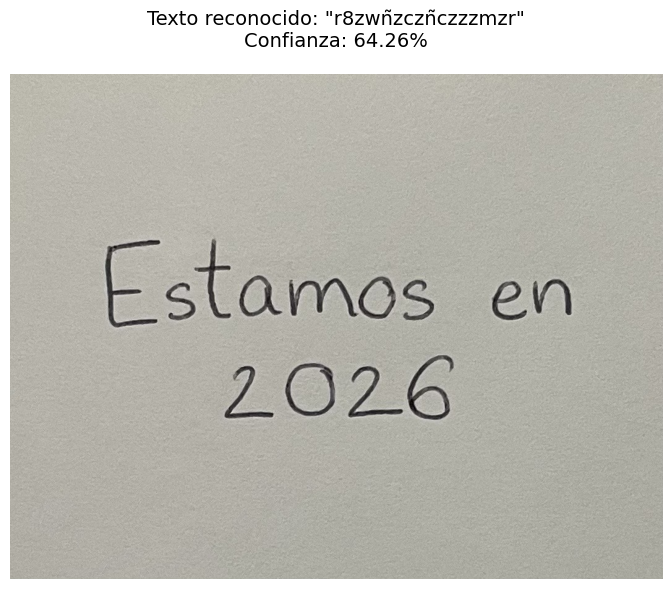


📝 Texto reconocido: r8zwñzczñczzzmzr
🎯 Confianza promedio: 64.26%

✅ Procesamiento completado


In [15]:
# ============================================================================
# CELDA 6: INTERFAZ PARA SUBIR Y RECONOCER IMÁGENES
# ============================================================================

def upload_and_recognize():
    """Interfaz para subir imagen y reconocer texto"""

    if model is None or label_to_char is None:
        print("❌ ERROR: Debes entrenar o cargar un modelo primero")
        return

    print("=" * 80)
    print("📤 SUBIR IMAGEN PARA RECONOCIMIENTO OCR")
    print("=" * 80)
    print("\n📎 Selecciona una imagen (jpg, png, bmp)...")

    # Subir archivo
    uploaded = files.upload()

    if not uploaded:
        print("❌ No se subió ninguna imagen")
        return

    # Procesar cada imagen subida
    for filename in uploaded.keys():
        print(f"\n🔍 Procesando: {filename}")
        print("-" * 80)

        # Guardar temporalmente
        temp_path = f"temp_{filename}"
        with open(temp_path, 'wb') as f:
            f.write(uploaded[filename])

        # Crear sistema OCR
        ocr = OCRSystem(model, label_to_char)

        # Reconocer y visualizar
        text, confidence = ocr.visualize_recognition(temp_path)

        print(f"\n📝 Texto reconocido: {text}")
        print(f"🎯 Confianza promedio: {confidence:.2%}")

        # Limpiar
        os.remove(temp_path)

    print("\n✅ Procesamiento completado")

# Ejecutar interfaz
upload_and_recognize()

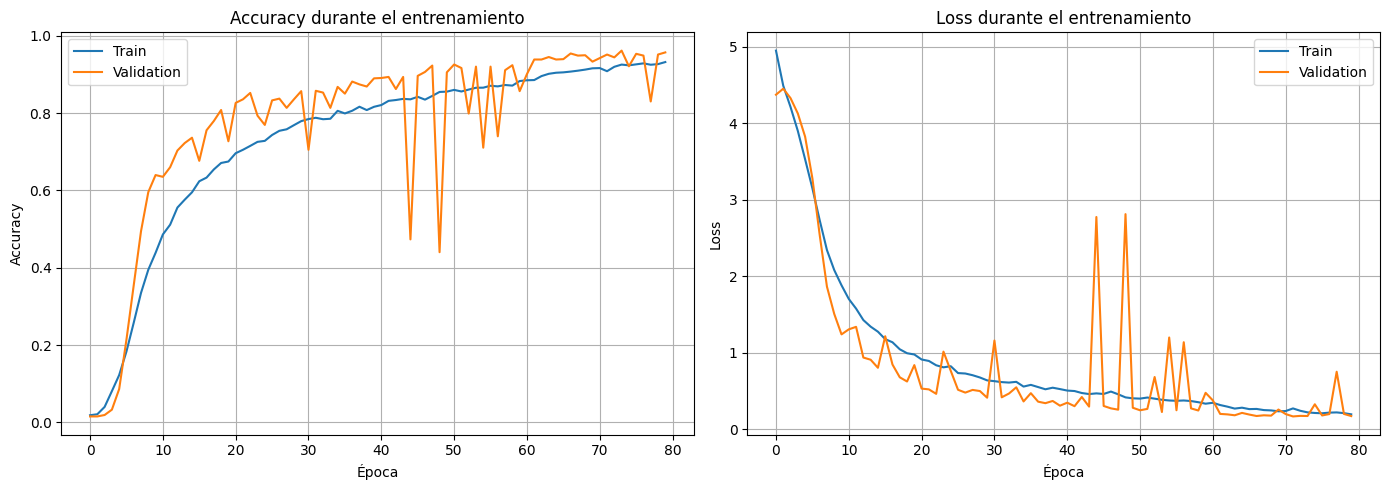

In [12]:
# ============================================================================
# CELDA 7: FUNCIONES DE EVALUACIÓN Y ANÁLISIS
# ============================================================================

def plot_training_history(history):
    """Grafica el historial de entrenamiento"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Accuracy durante el entrenamiento')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Loss durante el entrenamiento')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Graficar historial si existe
if model and hasattr(model, 'history') and model.history:
    plot_training_history(model.history)